In [ ]:
!pip install datasets

In [ ]:
import numpy as np
import librosa
import librosa.display
import tensorflow as tf
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
#loading dataset from Hugging Face
dataset = load_dataset("Hemg/Emotion-audio-Dataset", split="train")
# to load the full data we use train for the parameter split since its labeled as train from the uploader in hugging face

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/507 [00:00<?, ?B/s]

train-00000-of-00006.parquet:   0%|          | 0.00/269M [00:00<?, ?B/s]

train-00001-of-00006.parquet:   0%|          | 0.00/274M [00:00<?, ?B/s]

train-00002-of-00006.parquet:   0%|          | 0.00/263M [00:00<?, ?B/s]

train-00003-of-00006.parquet:   0%|          | 0.00/245M [00:00<?, ?B/s]

train-00004-of-00006.parquet:   0%|          | 0.00/278M [00:00<?, ?B/s]

train-00005-of-00006.parquet:   0%|          | 0.00/248M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12798 [00:00<?, ? examples/s]

In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12

In [ ]:

#some parameters
SAMPLE_RATE = 22050  #number of audio samples per second.
DURATION = 4 #length of the audio file we want to process in seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION #total number of audio samples in every track
N_MELS = 128 #2D "height" of your spectrogram image
#Number of Mel frequency bands used when computing the Mel spectrogram.
#Higher numbers = higher frequency resolution.
MAX_PAD_LEN = 128  # Time dimension after spectrogram
#2D "width" of the image; makes inputs uniform


# FIRST EXPRIMENT

### Trying to learn how to preprocess audio files for classification and building a first random cnn just to test

In [ ]:

#feature extraction
def extract_features_from_audio(example):
    audio_array = example['audio']['array']
    sr = example['audio']['sampling_rate']

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)
        #we do this so all clips are at the same sampling rate this is important in ml and nn

    if len(audio_array) < SAMPLES_PER_TRACK:
        pad_len = SAMPLES_PER_TRACK - len(audio_array)
        audio_array = np.pad(audio_array, (0, pad_len), mode='constant')
    else:
        audio_array  = audio_array[:SAMPLES_PER_TRACK]

      #making sure all the audio clips are the same length so we either make them shorter or pad them with zeroes

    mels = librosa.feature.melspectrogram(y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS)
      #turning waveform into a Mel spectrogram: a 2D array (shape: n_mels × time) showing energy in different frequency bands over time.

    log_mels = librosa.power_to_db(mels, ref=np.max)
    #logarithmic scale is closer to how humans perceive loudness.

    if log_mels.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - log_mels.shape[1]
        log_mels = np.pad(log_mels, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mels = log_mels[:, :MAX_PAD_LEN]

    #pad/trim to fixed width

    return log_mels.astype(np.float32)



In [ ]:
#extract features & labels
X, y = [], []
#X will store the spectrograms (features), and y stores the corresponding emotion labels.

for example in dataset:
    try:
        features = extract_features_from_audio(example)
        X.append(features)
        y.append(example["label"])
    except Exception as e:
        print(f"Error processing example: {e}")

X = np.array(X)#list of spectrograms to a 3D NumPy array: (num_samples, 128, 128)
X = X[..., np.newaxis]  # cNN channel dimension (num_samples, 128, 128, 1)   This is just like a grayscale image for a CNN.
X /= np.max(X) # normalizes the pixel values to be between 0 and 1 — this improves training stability.



<ipython-input-5-f7f215d8be1c>:15: RuntimeWarning: divide by zero encountered in divide
  X /= np.max(X) # normalizes the pixel values to be between 0 and 1 — this improves training stability.
<ipython-input-5-f7f215d8be1c>:15: RuntimeWarning: invalid value encountered in divide
  X /= np.max(X) # normalizes the pixel values to be between 0 and 1 — this improves training stability.


In [ ]:
#encode labels
le = LabelEncoder() # turns emotions into numbers
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
#this is needed for categorical_crossentropy loss.

In [ ]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)



In [ ]:
#build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#categorical_crossentropy is appropriate loss function for multiclass classification when using one-hot labels.



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#train model
model.fit(X_train, y_train, epochs=10, batch_size=32)



Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.0435 - loss: nan
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0469 - loss: nan
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0466 - loss: nan
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0442 - loss: nan
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0481 - loss: nan
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0475 - loss: nan
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0489 - loss: nan
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0449 - loss: nan
Epoch 9/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.0431 - loss: nan
Epoch 10/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0467 - loss: nan


In [ ]:
#evaluatation
test_loss, test_acc = model.evaluate(X_test, y_test)
print("✅ Test Accuracy:", test_acc)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0390 - loss: nan
✅ Test Accuracy: 0.04648437350988388


# SECOND EXPIREMENT

### Fixed issues with handling the dataset where empty and corrupted audio files weren't being skipped  (handling NaN and INF values)

###fixed problem with handling normlization where it would try to divide by zero

In [ ]:

#feature extraction
def extract_features_from_audio(example):
    audio_array = example['audio']['array']
    sr = example['audio']['sampling_rate']

       #if the audio array is empty just skip the track
    if len(audio_array) == 0:
        print("Skipping empty audio")
        return None

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)
        #we do this so all clips are at the same sampling rate this is important in ml

    if len(audio_array) < SAMPLES_PER_TRACK:
        pad_len = SAMPLES_PER_TRACK - len(audio_array)
        audio_array = np.pad(audio_array, (0, pad_len), mode='constant')
    else:
        audio_array  = audio_array[:SAMPLES_PER_TRACK]

      #making sure all the audio clips are the same length so we either make them shorter or pad them with zeroes

    mels = librosa.feature.melspectrogram(y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS)
      #turning waveform into a Mel spectrogram: a 2D array (shape: n_mels × time) showing energy in different frequency bands over time.

    log_mels = librosa.power_to_db(mels, ref=np.max)
    #logarithmic scale is closer to how humans perceive loudness.

    if log_mels.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - log_mels.shape[1]
        log_mels = np.pad(log_mels, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mels = log_mels[:, :MAX_PAD_LEN]

    #pad/Trim to fixed width

     #check for NaNs/Infs in the log-mels features
    if np.isnan(log_mels).any() or np.isinf(log_mels).any():
        print("Skipping corrupted audio (NaN or Inf in features)")
        return None

    return log_mels.astype(np.float32)



In [ ]:
#  Extract features & labels
X, y = [], []
#X will store the spectrograms (features), and y stores the corresponding emotion labels.

for example in dataset:
    try:
        features = extract_features_from_audio(example)
        if features is not None:  #skip bad audio
          X.append(features)
          y.append(example["label"])
    except Exception as e:
        print(f"Error processing example: {e}")

X = np.array(X)#list of spectrograms to a 3D NumPy array: (num_samples, 128, 128)
X = X[..., np.newaxis]  # CNN channel dimension (num_samples, 128, 128, 1)   This is just like a grayscale image for a CNN.

#clean remaining NaNs and Infs (if any) just in case
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

#guard against divide-by-zero
max_val = np.max(X)
if max_val > 0:
    X /= max_val
else:
    print("Warning: max(X) is 0, skipping normalization.")

 # normalizes the pixel values to be between 0 and 1 — this improves training stability.



In [ ]:
print("NaNs in X:", np.isnan(X).sum())
print("Infs in X:", np.isinf(X).sum())


NaNs in X: 0
Infs in X: 0


In [ ]:
#encode labels
le = LabelEncoder() # turns emotions into numbers
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
#this is needed for categorical_crossentropy loss.

In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)



In [ ]:
#build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))





Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3592 - loss: 6.0068 - val_accuracy: 0.4461 - val_loss: 1.3667
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5597 - loss: 1.1107 - val_accuracy: 0.5781 - val_loss: 1.0793
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6475 - loss: 0.9266 - val_accuracy: 0.6027 - val_loss: 1.0593
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6868 - loss: 0.8132 - val_accuracy: 0.5871 - val_loss: 1.0796
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7536 - loss: 0.6665 - val_accuracy: 0.5887 - val_loss: 1.1359
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7890 - loss: 0.5729 - val_accuracy: 0.5734 - val_loss: 1.3135
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8325 - loss: 0.4662 - val_accuracy: 0.5723 - val_loss: 1.5827
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8602 - loss: 0.3789 - val_

In [ ]:
#evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print("✅ Test Accuracy:", test_acc)


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5670 - loss: 2.0472
✅ Test Accuracy: 0.5726562738418579


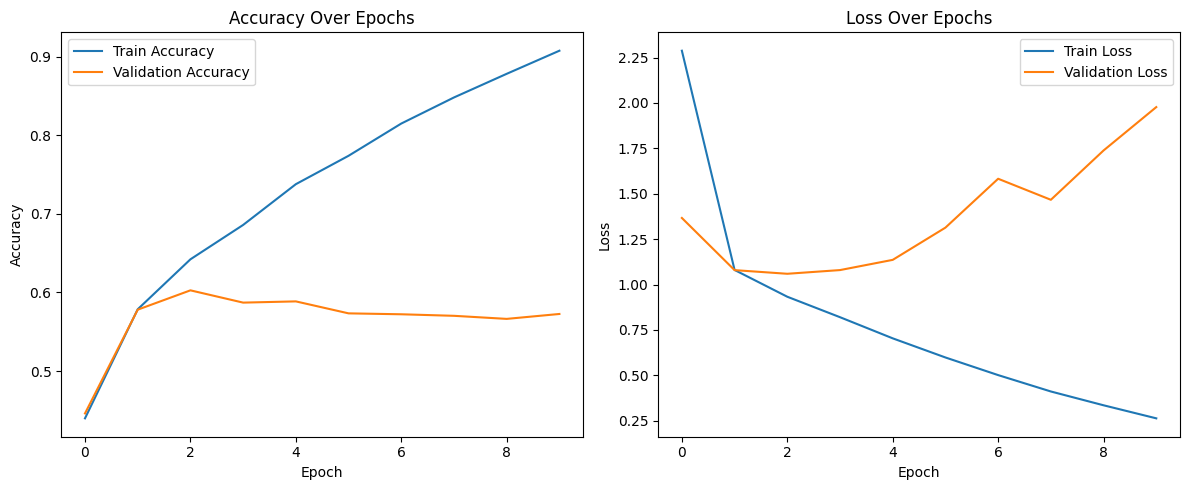

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### we can see that there is a clear overfitting so we are going to try to solve that now in the next experiment

# THIRD EXPIREMENT

### modifying the parameters (epochs=30, batch_size=64) increasing the epochs and also the batch size to try to solve overfitting

In [ ]:

#feature extraction
def extract_features_from_audio(example):
    audio_array = example['audio']['array']
    sr = example['audio']['sampling_rate']

       #if the audio array is empty just skip the track
    if len(audio_array) == 0:
        print("Skipping empty audio")
        return None

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)
        #we do this so all clips are at the same sampling rate this is important in ml

    if len(audio_array) < SAMPLES_PER_TRACK:
        pad_len = SAMPLES_PER_TRACK - len(audio_array)
        audio_array = np.pad(audio_array, (0, pad_len), mode='constant')
    else:
        audio_array  = audio_array[:SAMPLES_PER_TRACK]

      #making sure all the audio clips are the same length so we either make them shorter or pad them with zeroes

    mels = librosa.feature.melspectrogram(y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS)
      #turning waveform into a Mel spectrogram: a 2D array (shape: n_mels × time) showing energy in different frequency bands over time.

    log_mels = librosa.power_to_db(mels, ref=np.max)
    #logarithmic scale is closer to how humans perceive loudness.

    if log_mels.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - log_mels.shape[1]
        log_mels = np.pad(log_mels, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mels = log_mels[:, :MAX_PAD_LEN]

    #pad/Trim to fixed width

     #check for NaNs/Infs in the log-mels features
    if np.isnan(log_mels).any() or np.isinf(log_mels).any():
        print("Skipping corrupted audio (NaN or Inf in features)")
        return None

    return log_mels.astype(np.float32)



In [ ]:
#  Extract features & labels
X, y = [], []
#X will store the spectrograms (features), and y stores the corresponding emotion labels.

for example in dataset:
    try:
        features = extract_features_from_audio(example)
        if features is not None:  #skip bad audio
          X.append(features)
          y.append(example["label"])
    except Exception as e:
        print(f"Error processing example: {e}")

X = np.array(X)#list of spectrograms to a 3D NumPy array: (num_samples, 128, 128)
X = X[..., np.newaxis]  # CNN channel dimension (num_samples, 128, 128, 1)   This is just like a grayscale image for a CNN.

#clean remaining NaNs and Infs (if any) just in case
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

#guard against divide-by-zero
max_val = np.max(X)
if max_val > 0:
    X /= max_val
else:
    print("Warning: max(X) is 0, skipping normalization.")

 # normalizes the pixel values to be between 0 and 1 — this improves training stability.



In [ ]:
print("NaNs in X:", np.isnan(X).sum())
print("Infs in X:", np.isinf(X).sum())


NaNs in X: 0
Infs in X: 0


In [ ]:
#encode labels
le = LabelEncoder() # turns emotions into numbers
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
#this is needed for categorical_crossentropy loss.

In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)



In [ ]:
#build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#train model
history = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_test, y_test))




Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.2888 - loss: 4.4319 - val_accuracy: 0.5367 - val_loss: 1.1764
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5622 - loss: 1.1104 - val_accuracy: 0.5820 - val_loss: 1.0643
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6470 - loss: 0.9139 - val_accuracy: 0.5754 - val_loss: 1.0904
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6988 - loss: 0.7933 - val_accuracy: 0.5965 - val_loss: 1.0885
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7487 - loss: 0.6657 - val_accuracy: 0.6102 - val_loss: 1.0545
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8074 - loss: 0.5202 - val_accuracy: 0.6145 - val_loss: 1.2181
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8477 - loss: 0.4276 - val_accuracy: 0.6094 - val_loss: 1.3250
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8892 - loss: 0.3128 - val_acc

In [ ]:
#evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("✅ Test Accuracy:", test_acc)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5838 - loss: 4.0327
✅ Test Accuracy: 0.6015625


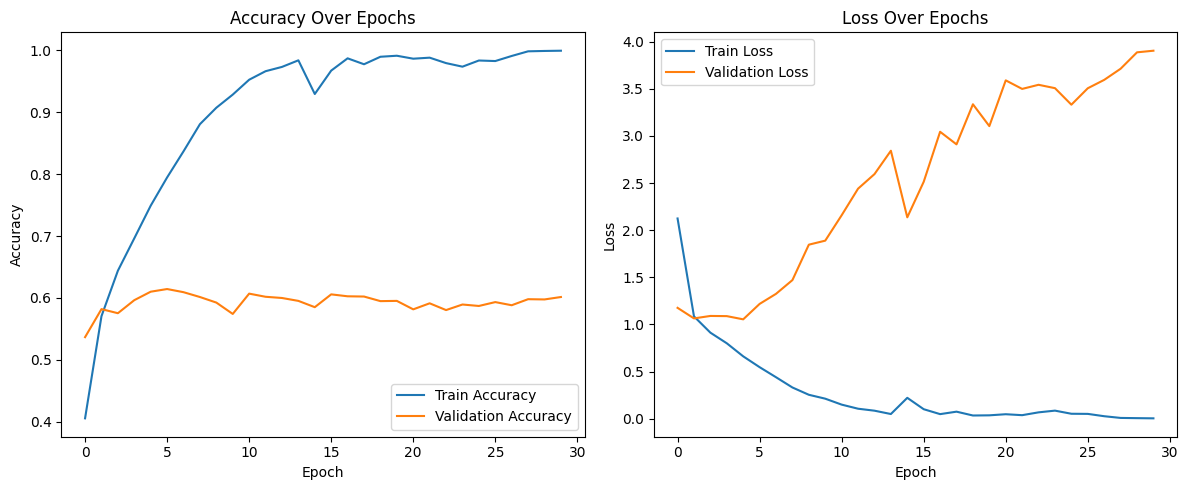

In [ ]:
# plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


#Fourth Expriement

### added dropout layers and early stoping to try and solve overfitting

In [ ]:

#feature extraction
def extract_features_from_audio(example):
    audio_array = example['audio']['array']
    sr = example['audio']['sampling_rate']

       #if the audio array is empty just skip the track
    if len(audio_array) == 0:
        print("Skipping empty audio")
        return None

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)
        #we do this so all clips are at the same sampling rate this is important in ml

    if len(audio_array) < SAMPLES_PER_TRACK:
        pad_len = SAMPLES_PER_TRACK - len(audio_array)
        audio_array = np.pad(audio_array, (0, pad_len), mode='constant')
    else:
        audio_array  = audio_array[:SAMPLES_PER_TRACK]

      #making sure all the audio clips are the same length so we either make them shorter or pad them with zeroes

    mels = librosa.feature.melspectrogram(y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS)
      #turning waveform into a Mel spectrogram: a 2D array (shape: n_mels × time) showing energy in different frequency bands over time.

    log_mels = librosa.power_to_db(mels, ref=np.max)
    #logarithmic scale is closer to how humans perceive loudness.

    if log_mels.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - log_mels.shape[1]
        log_mels = np.pad(log_mels, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mels = log_mels[:, :MAX_PAD_LEN]

    #pad/Trim to fixed width

     #check for NaNs/Infs in the log-mels features
    if np.isnan(log_mels).any() or np.isinf(log_mels).any():
        print("Skipping corrupted audio (NaN or Inf in features)")
        return None

    return log_mels.astype(np.float32)



In [ ]:
# extract features & labels
X, y = [], []
#X will store the spectrograms (features), and y stores the corresponding emotion labels.

for example in dataset:
    try:
        features = extract_features_from_audio(example)
        if features is not None:  #skip bad audio
          X.append(features)
          y.append(example["label"])
    except Exception as e:
        print(f"Error processing example: {e}")

X = np.array(X)#list of spectrograms to a 3D NumPy array: (num_samples, 128, 128)
X = X[..., np.newaxis]  # CNN channel dimension (num_samples, 128, 128, 1)   This is just like a grayscale image for a CNN.

#clean remaining NaNs and Infs (if any) just in case
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

#guard against divide-by-zero
max_val = np.max(X)
if max_val > 0:
    X /= max_val
else:
    print("Warning: max(X) is 0, skipping normalization.")

 # normalizes the pixel values to be between 0 and 1 — this improves training stability.



In [ ]:
print("NaNs in X:", np.isnan(X).sum())
print("Infs in X:", np.isinf(X).sum())


In [ ]:
#encode labels
le = LabelEncoder() # turns emotions into numbers
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
#this is needed for categorical_crossentropy loss.

In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)



In [ ]:
#build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    #small values of dropout in the start of the neural netowrks to not hurt the learning
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    #biger dopouut in the deeper parts of the neural networks to prevent the overfitting
    layers.Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
#train model

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[callback]
)
#adding early stopping to stop training once the the validation loss stops improving



Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.1675 - loss: 8.8272 - val_accuracy: 0.1570 - val_loss: 1.9139
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1707 - loss: 1.9053 - val_accuracy: 0.2305 - val_loss: 1.8012
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.2713 - loss: 1.7436 - val_accuracy: 0.3836 - val_loss: 1.5107
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3668 - loss: 1.5502 - val_accuracy: 0.4117 - val_loss: 1.4492
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4309 - loss: 1.4212 - val_accuracy: 0.4875 - val_loss: 1.2726
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4512 - loss: 1.3342 - val_accuracy: 0.4789 - val_loss: 1.2469
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4917 - loss: 1.2492 - val_accuracy: 0.4887 - val_loss: 1.2239
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5181 - loss: 1.1919 - val_acc

In [ ]:
#evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("✅ Test Accuracy:", test_acc)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5738 - loss: 1.0650
✅ Test Accuracy: 0.608593761920929


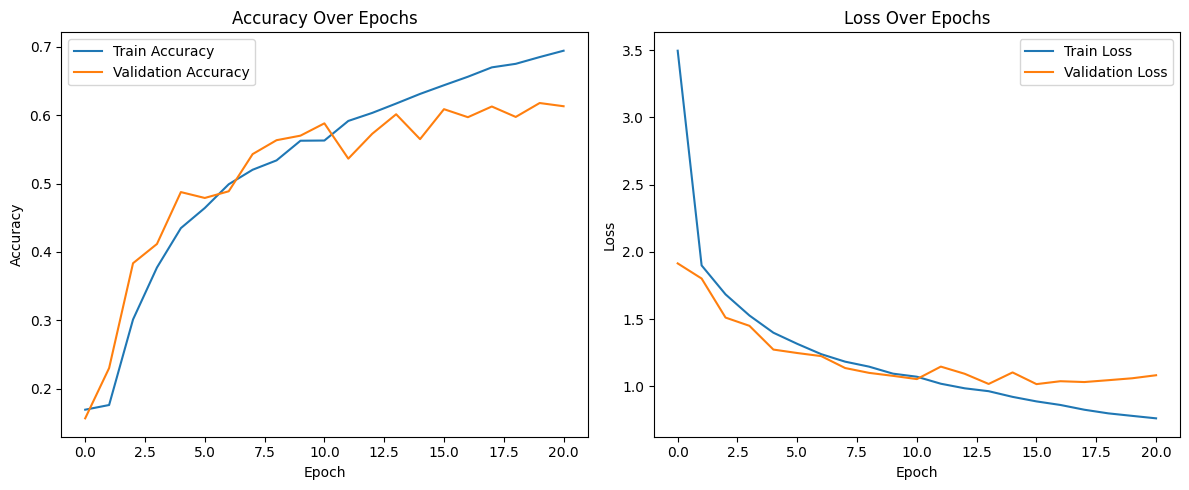

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


###now that overfitting is mostly solved let's try improving the test accuracy

#Fifth Expriement

###added batch normalization for the conv layers and l2(0.01) regulaizer for the dense layer

In [ ]:

#feature extraction
def extract_features_from_audio(example):
    audio_array = example['audio']['array']
    sr = example['audio']['sampling_rate']

       #if the audio array is empty just skip the track
    if len(audio_array) == 0:
        print("Skipping empty audio")
        return None

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)
        #we do this so all clips are at the same sampling rate this is important in ml

    if len(audio_array) < SAMPLES_PER_TRACK:
        pad_len = SAMPLES_PER_TRACK - len(audio_array)
        audio_array = np.pad(audio_array, (0, pad_len), mode='constant')
    else:
        audio_array  = audio_array[:SAMPLES_PER_TRACK]

      #making sure all the audio clips are the same length so we either make them shorter or pad them with zeroes

    mels = librosa.feature.melspectrogram(y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS)
      #turning waveform into a Mel spectrogram: a 2D array (shape: n_mels × time) showing energy in different frequency bands over time.

    log_mels = librosa.power_to_db(mels, ref=np.max)
    #logarithmic scale is closer to how humans perceive loudness.

    if log_mels.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - log_mels.shape[1]
        log_mels = np.pad(log_mels, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mels = log_mels[:, :MAX_PAD_LEN]

    #pad/Trim to fixed width

     #check for NaNs/Infs in the log-mels features
    if np.isnan(log_mels).any() or np.isinf(log_mels).any():
        print("Skipping corrupted audio (NaN or Inf in features)")
        return None

    return log_mels.astype(np.float32)



In [ ]:
# extract features & labels
X, y = [], []
#X will store the spectrograms (features), and y stores the corresponding emotion labels.

for example in dataset:
    try:
        features = extract_features_from_audio(example)
        if features is not None:  #skip bad audio
          X.append(features)
          y.append(example["label"])
    except Exception as e:
        print(f"Error processing example: {e}")

X = np.array(X)#list of spectrograms to a 3D NumPy array: (num_samples, 128, 128)
X = X[..., np.newaxis]  # CNN channel dimension (num_samples, 128, 128, 1)   This is just like a grayscale image for a CNN.

#clean remaining NaNs and Infs (if any) just in case
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

#guard against divide-by-zero
max_val = np.max(X)
if max_val > 0:
    X /= max_val
else:
    print("Warning: max(X) is 0, skipping normalization.")

 # normalizes the pixel values to be between 0 and 1 — this improves training stability.



In [ ]:
print("NaNs in X:", np.isnan(X).sum())
print("Infs in X:", np.isinf(X).sum())


NaNs in X: 0
Infs in X: 0


In [ ]:
#encode labels
le = LabelEncoder() # turns emotions into numbers
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
#this is needed for categorical_crossentropy loss.

In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)



In [ ]:
from keras.layers import Dense, Dropout, BatchNormalization
from keras.regularizers import l2

#build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
     BatchNormalization(),
    #small values of dropout in the start of the neural netowrks to not hurt the learning
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
     BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu', kernel_regularizer = l2(0.01)),
    layers.Dropout(0.5),
     BatchNormalization(),
    #biger dopouut in the deeper parts of the neural networks to prevent the overfitting
    layers.Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#train model

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[callback],
)
#adding early stopping to stop training once the the validation loss stops improving



Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5807 - loss: 1.4029 - val_accuracy: 0.3926 - val_loss: 3.0395
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.6000 - loss: 1.3701 - val_accuracy: 0.4992 - val_loss: 1.6193
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5964 - loss: 1.3937 - val_accuracy: 0.5957 - val_loss: 1.3817
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6119 - loss: 1.3418 - val_accuracy: 0.5367 - val_loss: 1.5534
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6116 - loss: 1.3541 - val_accuracy: 0.4480 - val_loss: 2.8134
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.6238 - loss: 1.3490 - val_accuracy: 0.5137 - val_loss: 1.5582
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6070 - loss: 1.3866 - val_accuracy: 0.5691 - val_loss: 1.4758
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6435 - loss: 1.3394 - val_a

In [ ]:
#evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("✅ Test Accuracy:", test_acc)


80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5853 - loss: 1.4023
✅ Test Accuracy: 0.595703125


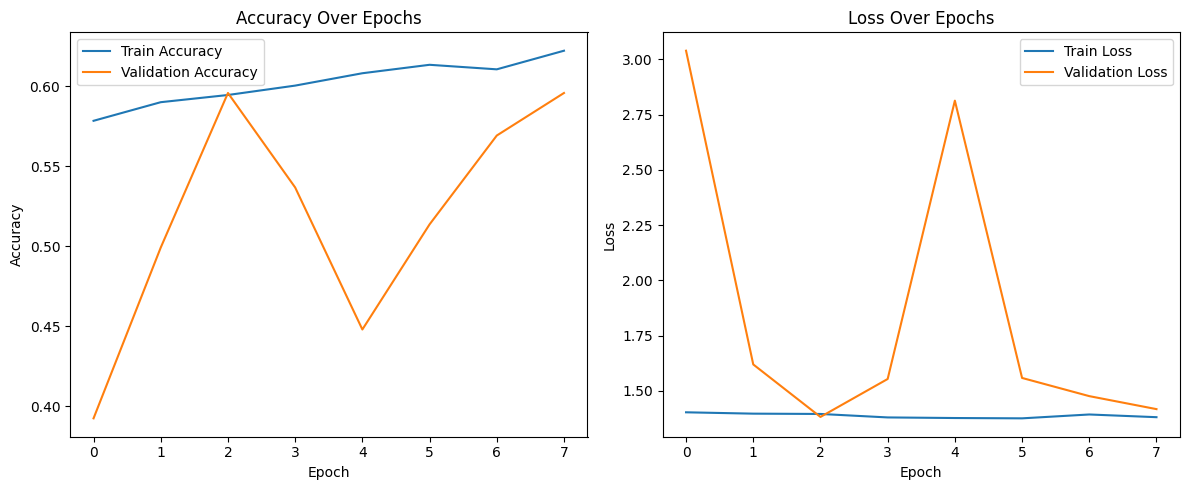

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


#Sixth Expriement

### removed batch normalization

In [ ]:

#feature extraction
def extract_features_from_audio(example):
    audio_array = example['audio']['array']
    sr = example['audio']['sampling_rate']

       #if the audio array is empty just skip the track
    if len(audio_array) == 0:
        print("Skipping empty audio")
        return None

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)
        #we do this so all clips are at the same sampling rate this is important in ml

    if len(audio_array) < SAMPLES_PER_TRACK:
        pad_len = SAMPLES_PER_TRACK - len(audio_array)
        audio_array = np.pad(audio_array, (0, pad_len), mode='constant')
    else:
        audio_array  = audio_array[:SAMPLES_PER_TRACK]

      #making sure all the audio clips are the same length so we either make them shorter or pad them with zeroes

    mels = librosa.feature.melspectrogram(y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS)
      #turning waveform into a Mel spectrogram: a 2D array (shape: n_mels × time) showing energy in different frequency bands over time.

    log_mels = librosa.power_to_db(mels, ref=np.max)
    #logarithmic scale is closer to how humans perceive loudness.

    if log_mels.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - log_mels.shape[1]
        log_mels = np.pad(log_mels, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mels = log_mels[:, :MAX_PAD_LEN]

    #pad/Trim to fixed width

     #check for NaNs/Infs in the log-mels features
    if np.isnan(log_mels).any() or np.isinf(log_mels).any():
        print("Skipping corrupted audio (NaN or Inf in features)")
        return None

    return log_mels.astype(np.float32)



In [ ]:
# extract features & labels
X, y = [], []
#X will store the spectrograms (features), and y stores the corresponding emotion labels.

for example in dataset:
    try:
        features = extract_features_from_audio(example)
        if features is not None:  #skip bad audio
          X.append(features)
          y.append(example["label"])
    except Exception as e:
        print(f"Error processing example: {e}")

X = np.array(X)#list of spectrograms to a 3D NumPy array: (num_samples, 128, 128)
X = X[..., np.newaxis]  # CNN channel dimension (num_samples, 128, 128, 1)   This is just like a grayscale image for a CNN.

#clean remaining NaNs and Infs (if any) just in case
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

#guard against divide-by-zero
max_val = np.max(X)
if max_val > 0:
    X /= max_val
else:
    print("Warning: max(X) is 0, skipping normalization.")

 # normalizes the pixel values to be between 0 and 1 — this improves training stability.



In [ ]:
print("NaNs in X:", np.isnan(X).sum())
print("Infs in X:", np.isinf(X).sum())


NaNs in X: 0
Infs in X: 0


In [ ]:
#encode labels
le = LabelEncoder() # turns emotions into numbers
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
#this is needed for categorical_crossentropy loss.

In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)



In [ ]:
import keras

#build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    #small values of dropout in the start of the neural netowrks to not hurt the learning
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    #biger dopouut in the deeper parts of the neural networks to prevent the overfitting
    layers.Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#train model

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[callback]
)
#adding early stopping to stop training once the the validation loss stops improving



Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.1579 - loss: 7.0361 - val_accuracy: 0.1570 - val_loss: 1.9221
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1672 - loss: 1.9151 - val_accuracy: 0.1570 - val_loss: 1.9051
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1731 - loss: 1.9030 - val_accuracy: 0.1570 - val_loss: 1.8992
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1664 - loss: 1.8977 - val_accuracy: 0.1570 - val_loss: 1.8975
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.1769 - loss: 1.8952 - val_accuracy: 0.1570 - val_loss: 1.8965
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1669 - loss: 1.8978 - val_accuracy: 0.1570 - val_loss: 1.8969
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.1642 - loss: 1.8982 - val_accuracy: 0.1570 - val_loss: 1.8967
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.1616 - loss: 1.8982 - val_acc

In [ ]:
#evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("✅ Test Accuracy:", test_acc)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1573 - loss: 1.9052
✅ Test Accuracy: 0.15703125298023224


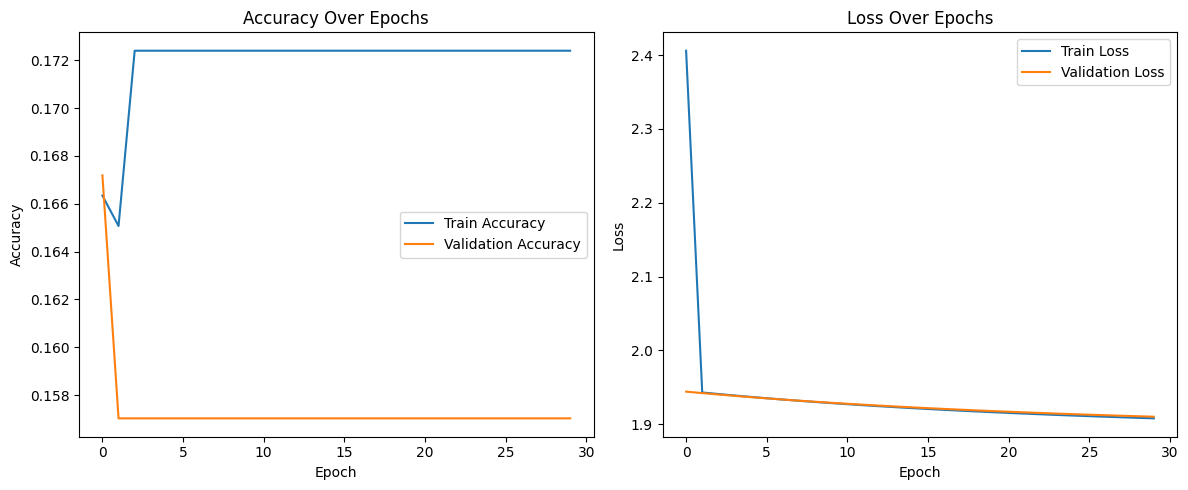

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


#Seventh Expriement

### added learning rate scheduling and added back batch normalization

In [ ]:

#feature extraction
def extract_features_from_audio(example):
    audio_array = example['audio']['array']
    sr = example['audio']['sampling_rate']

       #if the audio array is empty just skip the track
    if len(audio_array) == 0:
        print("Skipping empty audio")
        return None

    if sr != SAMPLE_RATE:
        audio_array = librosa.resample(audio_array, orig_sr=sr, target_sr=SAMPLE_RATE)
        #we do this so all clips are at the same sampling rate this is important in ml

    if len(audio_array) < SAMPLES_PER_TRACK:
        pad_len = SAMPLES_PER_TRACK - len(audio_array)
        audio_array = np.pad(audio_array, (0, pad_len), mode='constant')
    else:
        audio_array  = audio_array[:SAMPLES_PER_TRACK]

      #making sure all the audio clips are the same length so we either make them shorter or pad them with zeroes

    mels = librosa.feature.melspectrogram(y=audio_array, sr=SAMPLE_RATE, n_mels=N_MELS)
      #turning waveform into a Mel spectrogram: a 2D array (shape: n_mels × time) showing energy in different frequency bands over time.

    log_mels = librosa.power_to_db(mels, ref=np.max)
    #logarithmic scale is closer to how humans perceive loudness.

    if log_mels.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - log_mels.shape[1]
        log_mels = np.pad(log_mels, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mels = log_mels[:, :MAX_PAD_LEN]

    #pad/Trim to fixed width

     #check for NaNs/Infs in the log-mels features
    if np.isnan(log_mels).any() or np.isinf(log_mels).any():
        print("Skipping corrupted audio (NaN or Inf in features)")
        return None

    return log_mels.astype(np.float32)



In [ ]:
# extract features & labels
X, y = [], []
#X will store the spectrograms (features), and y stores the corresponding emotion labels.

for example in dataset:
    try:
        features = extract_features_from_audio(example)
        if features is not None:  #skip bad audio
          X.append(features)
          y.append(example["label"])
    except Exception as e:
        print(f"Error processing example: {e}")

X = np.array(X)#list of spectrograms to a 3D NumPy array: (num_samples, 128, 128)
X = X[..., np.newaxis]  # CNN channel dimension (num_samples, 128, 128, 1)   This is just like a grayscale image for a CNN.

#clean remaining NaNs and Infs (if any) just in case
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

#guard against divide-by-zero
max_val = np.max(X)
if max_val > 0:
    X /= max_val
else:
    print("Warning: max(X) is 0, skipping normalization.")

 # normalizes the pixel values to be between 0 and 1 — this improves training stability.



In [ ]:
print("NaNs in X:", np.isnan(X).sum())
print("Infs in X:", np.isinf(X).sum())


NaNs in X: 0
Infs in X: 0


In [ ]:
#encode labels
le = LabelEncoder() # turns emotions into numbers
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)
#this is needed for categorical_crossentropy loss.

In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)



In [ ]:
from keras.layers import Dense, Dropout, BatchNormalization
from keras.regularizers import l2

#build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
     BatchNormalization(),
    #small values of dropout in the start of the neural netowrks to not hurt the learning
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
     BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu', kernel_regularizer = l2(0.01)),
    layers.Dropout(0.5),
     BatchNormalization(),
    #biger dopouut in the deeper parts of the neural networks to prevent the overfitting
    layers.Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#learning rate schedule function
def lr_schedule(epoch, lr):
    if epoch < 10:
        return lr
    elif epoch < 20:
        return lr * 0.1
    else:
        return lr * 0.01

#learning rate scheduler callback
lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#train model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping_callback, lr_callback]
)
#adding early stopping to stop training once the the validation loss stops improving



Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.3086 - loss: 2.9996 - val_accuracy: 0.4680 - val_loss: 1.8810 - learning_rate: 0.0010
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.4624 - loss: 1.7199 - val_accuracy: 0.3582 - val_loss: 1.9588 - learning_rate: 0.0010
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.4919 - loss: 1.5981 - val_accuracy: 0.3773 - val_loss: 1.8946 - learning_rate: 0.0010
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5169 - loss: 1.5842 - val_accuracy: 0.3449 - val_loss: 2.0970 - learning_rate: 0.0010
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5317 - loss: 1.5614 - val_accuracy: 0.4504 - val_loss: 1.6692 - learning_rate: 0.0010
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5559 - loss: 1.4807 - val_accuracy: 0.5238 - val_loss: 1.5692 - learning_rate: 0.0010
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5605 - loss: 

In [ ]:
#evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("✅ Test Accuracy:", test_acc)


80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6036 - loss: 1.2893
✅ Test Accuracy: 0.611328125


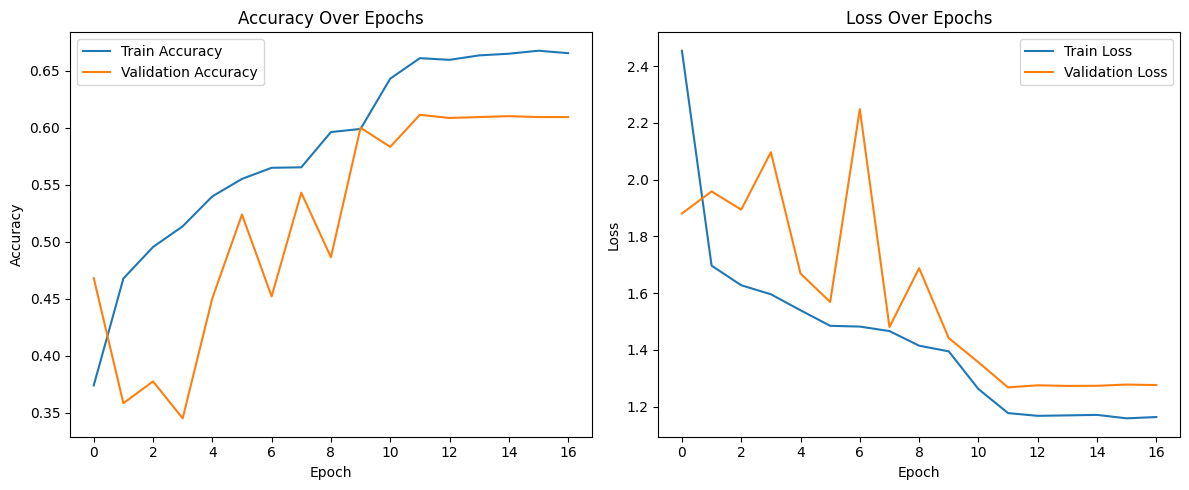

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Pretrained

In [ ]:
# from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification

# # Load the processor from the base model
# processor = Wav2Vec2Processor.from_pretrained("jonatasgrosman/wav2vec2-large-xlsr-53-english")

# # Load the fine-tuned model
# model = Wav2Vec2ForSequenceClassification.from_pretrained("ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition")


# Load model directly
from transformers import AutoProcessor, AutoModelForPreTraining

processor = AutoProcessor.from_pretrained("facebook/wav2vec2-large-xlsr-53")
model = AutoModelForPreTraining.from_pretrained("facebook/wav2vec2-large-xlsr-53")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/262 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.28k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Some weights of the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition were not used when initializing Wav2Vec2ForSequenceClassification: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.output.bias', 'classifier.output.weight']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition and are newly initialized: ['classifier.bias', 'classifier.weight', '

In [ ]:
labels = dataset.features["label"].names
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

NameError: name 'dataset' is not defined

In [ ]:
model = AutoModelForAudioClassification.from_pretrained(
    "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition",
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)


NameError: name 'AutoModelForAudioClassification' is not defined

In [ ]:
def preprocess(example):
    audio = example["audio"]
    inputs = processor(audio["array"], sampling_rate=audio["sampling_rate"], return_tensors="pt")
    inputs["label"] = example["label"]
    return inputs

processed_dataset = dataset.map(preprocess)


NameError: name 'dataset' is not defined

In [ ]:
import torch
torch.cuda.is_available()

False